In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import constants, units
from astropy.coordinates import Angle
from scipy.optimize import curve_fit
import pandas as pd
import os
from scipy.signal import medfilt
from astropy.wcs import WCS
import scipy.integrate as integrate
from astropy.coordinates import SkyCoord
from gwcs.wcstools import wcs_from_points
import astropy.coordinates as coord
from matplotlib.lines import Line2D

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Load in the full catalog

In [4]:
df = pd.read_csv(rootdir+'ldss_photometry_final.dat')

In [5]:
df

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z
0,231.087168,9.960573,-1,1,-1,-1,-1.0000,21.0268,-1.0000,-1.0,-1.0,-1.0,-1.0
1,231.087489,9.959768,-1,2,-1,-1,-1.0000,19.7528,-1.0000,-1.0,-1.0,-1.0,-1.0
2,231.117414,9.965209,-1,3,6078,-1,-1.0000,21.1236,27.4169,-1.0,-1.0,-1.0,-1.0
3,231.118874,9.964124,-1,4,-1,-1,-1.0000,19.4755,-1.0000,-1.0,-1.0,-1.0,-1.0
4,231.091003,9.953546,-1,5,-1,-1,-1.0000,24.3223,-1.0000,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109,231.092065,9.987828,1024,1110,3545,-1,23.5290,24.0699,27.5635,-1.0,-1.0,-1.0,-1.0
1110,231.115924,9.960328,1082,1111,-1,-1,24.7600,25.1467,-1.0000,-1.0,-1.0,-1.0,-1.0
1111,231.099188,9.989843,1064,1112,3581,-1,23.8963,23.6488,26.8201,-1.0,-1.0,-1.0,-1.0
1112,231.087197,9.986323,-1,1113,-1,-1,-1.0000,25.2002,-1.0000,-1.0,-1.0,-1.0,-1.0


Compute the separation of all objects from the QSO

In [6]:
df['theta'] = -1*np.ones(len(df))

In [7]:
def calc_phi(alpha_1, delta_1, alpha_2, delta_2):
    
    cos_phi = np.dot([np.cos(delta_1)*np.cos(alpha_1), np.cos(delta_1)*np.sin(alpha_1), np.sin(delta_1)],
                      [np.cos(delta_2)*np.cos(alpha_2), np.cos(delta_2)*np.sin(alpha_2), np.sin(delta_2)])
    
    phi = np.arccos(cos_phi)
    
    return phi

In [8]:
qso_ra = 231.1020901366564
qso_dec = 9.974869073268374

In [9]:
for i in range(len(df)):

    ra = Angle(df.loc[i]['RA'], units.deg).rad
    dec = Angle(df.loc[i]['Dec'], units.deg).rad

    df.loc[i,'theta'] = (calc_phi(ra, dec, qso_ra*np.pi/180, qso_dec*np.pi/180)*units.rad).to(units.arcsecond).value

In [10]:
df

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta
0,231.087168,9.960573,-1,1,-1,-1,-1.0000,21.0268,-1.0000,-1.0,-1.0,-1.0,-1.0,73.810571
1,231.087489,9.959768,-1,2,-1,-1,-1.0000,19.7528,-1.0000,-1.0,-1.0,-1.0,-1.0,75.071779
2,231.117414,9.965209,-1,3,6078,-1,-1.0000,21.1236,27.4169,-1.0,-1.0,-1.0,-1.0,64.507276
3,231.118874,9.964124,-1,4,-1,-1,-1.0000,19.4755,-1.0000,-1.0,-1.0,-1.0,-1.0,70.976585
4,231.091003,9.953546,-1,5,-1,-1,-1.0000,24.3223,-1.0000,-1.0,-1.0,-1.0,-1.0,86.243308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109,231.092065,9.987828,1024,1110,3545,-1,23.5290,24.0699,27.5635,-1.0,-1.0,-1.0,-1.0,58.650275
1110,231.115924,9.960328,1082,1111,-1,-1,24.7600,25.1467,-1.0000,-1.0,-1.0,-1.0,-1.0,71.737495
1111,231.099188,9.989843,1064,1112,3581,-1,23.8963,23.6488,26.8201,-1.0,-1.0,-1.0,-1.0,54.880701
1112,231.087197,9.986323,-1,1113,-1,-1,-1.0000,25.2002,-1.0000,-1.0,-1.0,-1.0,-1.0,66.996925


In [11]:
np.where(df['F160W_ID']==898)[0][0], np.where(df['F160W_ID']==727)[0][0], np.where(df['F160W_ID']==933)[0][0]

(884, 757, 941)

In [12]:
np.where(df['F160W_ID']==551)[0][0], np.where(df['F160W_ID']==20)[0][0], np.where(df['F160W_ID']==433)[0][0]

(536, 22, 328)

In [13]:
# LDSS m1 redshifts
df.iloc[884, df.columns.get_loc('z')] = 0.6518
df.iloc[757, df.columns.get_loc('z')] = 0.8404
df.iloc[941, df.columns.get_loc('z')] = 1.3316

# LDSS m2 redshifts
df.iloc[536, df.columns.get_loc('z')] = 1.4378
df.iloc[22, df.columns.get_loc('z')] = 1.2988
df.iloc[328, df.columns.get_loc('z')] = 0.6164

In [14]:
df

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta
0,231.087168,9.960573,-1,1,-1,-1,-1.0000,21.0268,-1.0000,-1.0,-1.0,-1.0,-1.0,73.810571
1,231.087489,9.959768,-1,2,-1,-1,-1.0000,19.7528,-1.0000,-1.0,-1.0,-1.0,-1.0,75.071779
2,231.117414,9.965209,-1,3,6078,-1,-1.0000,21.1236,27.4169,-1.0,-1.0,-1.0,-1.0,64.507276
3,231.118874,9.964124,-1,4,-1,-1,-1.0000,19.4755,-1.0000,-1.0,-1.0,-1.0,-1.0,70.976585
4,231.091003,9.953546,-1,5,-1,-1,-1.0000,24.3223,-1.0000,-1.0,-1.0,-1.0,-1.0,86.243308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109,231.092065,9.987828,1024,1110,3545,-1,23.5290,24.0699,27.5635,-1.0,-1.0,-1.0,-1.0,58.650275
1110,231.115924,9.960328,1082,1111,-1,-1,24.7600,25.1467,-1.0000,-1.0,-1.0,-1.0,-1.0,71.737495
1111,231.099188,9.989843,1064,1112,3581,-1,23.8963,23.6488,26.8201,-1.0,-1.0,-1.0,-1.0,54.880701
1112,231.087197,9.986323,-1,1113,-1,-1,-1.0000,25.2002,-1.0000,-1.0,-1.0,-1.0,-1.0,66.996925


Compute projected distances

In [15]:
def d_A(z, H0=70, Omega_m=0.3, Omega_lam=0.7):
    
    d_H = (constants.c/(H0*(units.km * units.s**-1 * units.Mpc**-1))).to(units.kpc)
    
    z_arr = np.arange(0, z+0.01, 0.01)
    E_arr = np.sqrt(Omega_m*(1+z_arr)**3 + Omega_lam)
    
    return ((1+z)**-1 * d_H * np.trapz(E_arr**-1, z_arr)).value

In [16]:
d_proj_arr = -np.ones(len(df))

for i in range(len(df)):
    if df.iloc[i]['z'] != -1:
        d_proj_arr[i] = d_A(df.iloc[i]['z'])*((df.iloc[i]['theta']*units.arcsec).to(units.radian)).value
    else:
        d_proj_arr[i] = -1

In [17]:
d_A(1)*((5*units.arcsec).to(units.radian)).value

40.04358713121987

In [18]:
df['d_proj'] = d_proj_arr

Now begin sorting, let us see the distribution of $\theta_{QSO}$

Text(0, 0.5, 'Counts')

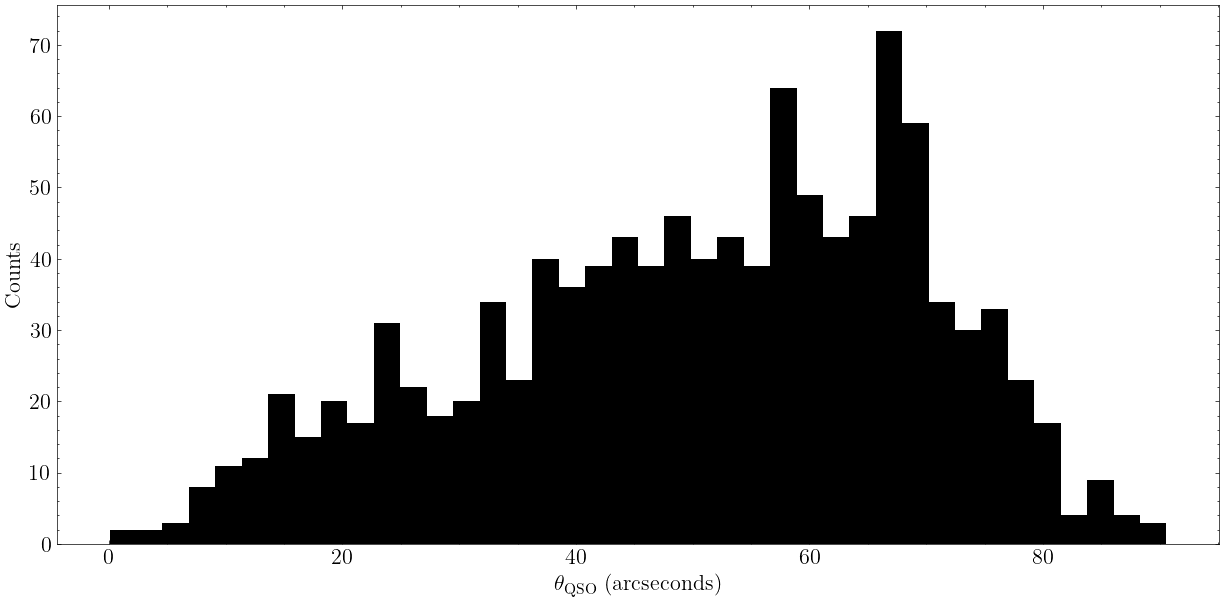

In [19]:
fig, ax = plt.subplots(1, figsize=(15,7))
ax.hist(df['theta'], bins=40)

ax.set_xlabel(r'$\theta_\mathrm{QSO}$ (arcseconds)')
ax.set_ylabel('Counts')

In [20]:
theta_partitions = [0,25,50,75,100]

In [21]:
df_sorted = pd.DataFrame(columns=df.columns)

In [22]:
for i in range(len(theta_partitions)-1):
    
    theta_min = theta_partitions[i]
    theta_max = theta_partitions[i+1]
    
    df_slice = df.loc[(df['theta']>=theta_min)&(df['theta']<=theta_max)].sort_values('f160w_mag')
        
    df_sorted = df_sorted.append(df_slice)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_44051/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_44051/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_44051/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_44051/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sort

In [23]:
df_sorted

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
461,231.106779,9.977776,-1,462,5809,-1,-1.0000,24.4336,28.6723,-1.0,-1.0,-1.0,-1.0,19.645115,-1.0
359,231.102371,9.980311,-1,360,5332,-1,-1.0000,25.2037,28.3803,-1.0,-1.0,-1.0,-1.0,19.617321,-1.0
486,231.108710,9.976795,-1,487,5967,-1,-1.0000,24.2128,28.2345,-1.0,-1.0,-1.0,-1.0,24.474540,-1.0
366,231.096338,9.978345,-1,367,5351,-1,-1.0000,25.5229,28.8657,-1.0,-1.0,-1.0,-1.0,23.926908,-1.0
367,231.105585,9.980689,-1,368,-1,-1,-1.0000,23.2307,-1.0000,-1.0,-1.0,-1.0,-1.0,24.342417,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,231.095469,9.955010,1059,20,-1,-1,23.9339,23.5250,-1.0000,-1.0,-1.0,-1.0,-1.0,75.247728,-1.0
33,231.119626,9.961601,1065,34,-1,-1,24.1524,23.7663,-1.0000,-1.0,-1.0,-1.0,-1.0,78.405662,-1.0
16,231.092634,9.955672,1022,17,-1,-1,24.1691,23.5231,-1.0000,-1.0,-1.0,-1.0,-1.0,76.813713,-1.0
5,231.091079,9.953079,4,6,-1,-1,24.3964,22.6563,-1.0000,-1.0,-1.0,-1.0,-1.0,87.624052,-1.0


In [24]:
df_sorted[df_sorted['z']==0.6780]

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
680,231.095876,9.967796,642,681,7247,105,22.0527,21.9529,24.3255,26.62,25.23,24.83,0.678,33.670872,238.077454


In [25]:
3e5*(0.6780-0.67546)/(1+0.67546)

454.8004727060206

In [26]:
#df_sorted[df_sorted['z']==0.7293]

In [27]:
df_sorted[df_sorted['z']==1.0959]

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
280,231.099645,9.981229,301,281,5066,27,24.1001,23.8175,26.0512,27.27,27.02,26.37,1.0959,24.480551,200.471151


In [28]:
3e5*(1.0959-1.09457)/(1+1.09457)

190.49255933199464

In [29]:
df_sorted[df_sorted['z']==1.2256]

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
451,231.098066,9.976266,465,452,5633,58,22.9471,22.9237,25.3929,26.43,25.96,25.37,1.2256,15.129536,126.161116


In [30]:
3e5*(1.2256-1.22541)/(1+1.22541)

25.61325778170033

In [31]:
df_sorted[df_sorted['z']==1.2787]

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
562,231.097977,9.970686,570,563,7389,87,21.891,21.7996,24.4112,27.21,26.16,25.05,1.2787,20.963146,175.426695


In [32]:
3e5*(1.2787-1.27767)/(1+1.27767)

135.66495585399082

In [33]:
df_spec_z = df_sorted[(df_sorted['z']!=-1) & (df_sorted['z']!=0) & (df_sorted['z']<=1.3276)].sort_values('z')

In [34]:
len(df_spec_z)

35

In [35]:
df_spec_z

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
264,231.101443,9.982304,286,265,4656,122,22.3238,22.4280,24.4433,25.21,24.75,24.70,0.0966,26.863312,49.697390
396,231.102849,9.976121,547,397,4179,52,16.7825,16.8165,17.8671,18.95,18.21,17.77,0.1203,5.247984,12.265723
395,231.103285,9.977136,544,396,5074,51,18.1347,18.2139,19.4546,20.07,19.52,19.21,0.1204,9.196677,21.492790
213,231.097267,9.983063,239,214,4638,20,22.6496,22.6584,24.3640,24.54,24.20,23.80,0.1393,34.097981,84.189245
529,231.096113,9.971428,541,530,7918,82,22.7515,22.6032,26.5490,26.85,26.49,26.23,0.2791,24.546576,104.250363
655,231.098099,9.969480,620,656,7228,96,23.9435,24.0014,26.4930,27.39,27.20,26.54,0.2915,24.013211,107.666094
555,231.101791,9.971945,563,556,6535,80,21.6297,21.6032,23.9751,24.56,23.94,23.59,0.3198,10.581162,49.264456
528,231.099016,9.971783,534,529,5792,79,19.1227,19.2642,20.4178,21.97,20.80,20.19,0.3286,15.562964,74.036258
700,231.105159,9.969736,705,701,6421,94,22.9127,22.8976,25.6831,25.62,24.93,24.73,0.3752,21.446580,112.031245
468,231.098210,9.974618,489,469,5843,65,23.3688,23.2136,25.8086,27.39,26.37,25.96,0.3759,13.786484,71.980298


In [36]:
z_list = [str(z) for z in df_spec_z['z']]
d_proj_list = [str(d) for d in df_spec_z['d_proj']]

In [37]:
CIV_EW_list = ['<44', '<50', '<49', '<49', '<105', 
               '<97',#'227, -32, +32', 
               '<157', '<123', '<93', 
               '<95', '<73', '<69', '<59', '<60', '<62', '<47', 
               '<48', 
               '<67', '<67','<67',#'254, -22, +22', '254, -22, +22', '254, -22, +22', 
               '<58','<46', '<52', '<52', 
               '157, -18, +18','<49', '<49', 
               '-10', '-10', '<174', '199, -3, +3', 
               '<12', '16, -3, +3', '176, -3, +3', '<8']

In [38]:
df_spec_z['CIV'] = CIV_EW_list

In [39]:
df_spec_z

,RA,Dec,F160W_ID,F140W_ID,F814W_ID,MUSE_ID,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj,CIV
264,231.101443,9.982304,286,265,4656,122,22.3238,22.4280,24.4433,25.21,24.75,24.70,0.0966,26.863312,49.697390,<44
396,231.102849,9.976121,547,397,4179,52,16.7825,16.8165,17.8671,18.95,18.21,17.77,0.1203,5.247984,12.265723,<50
395,231.103285,9.977136,544,396,5074,51,18.1347,18.2139,19.4546,20.07,19.52,19.21,0.1204,9.196677,21.492790,<49
213,231.097267,9.983063,239,214,4638,20,22.6496,22.6584,24.3640,24.54,24.20,23.80,0.1393,34.097981,84.189245,<49
529,231.096113,9.971428,541,530,7918,82,22.7515,22.6032,26.5490,26.85,26.49,26.23,0.2791,24.546576,104.250363,<105
655,231.098099,9.969480,620,656,7228,96,23.9435,24.0014,26.4930,27.39,27.20,26.54,0.2915,24.013211,107.666094,<97
555,231.101791,9.971945,563,556,6535,80,21.6297,21.6032,23.9751,24.56,23.94,23.59,0.3198,10.581162,49.264456,<157
528,231.099016,9.971783,534,529,5792,79,19.1227,19.2642,20.4178,21.97,20.80,20.19,0.3286,15.562964,74.036258,<123
700,231.105159,9.969736,705,701,6421,94,22.9127,22.8976,25.6831,25.62,24.93,24.73,0.3752,21.446580,112.031245,<93
468,231.098210,9.974618,489,469,5843,65,23.3688,23.2136,25.8086,27.39,26.37,25.96,0.3759,13.786484,71.980298,<95


In [40]:
df_spec_z.to_csv(rootdir+'gal_surv.csv')

Load modified catalog

In [41]:
df_spec_z_mod = pd.read_csv(rootdir+'gal_surv_complete.csv')

In [42]:
df_spec_z_mod

,MUSE_ID,F814W_ID,F140W_ID,F160W_ID,RA,Dec,E(B-V),z_gal,theta,d_proj,...,Mr,Mg,MB,u-g,M_star_KC,M_star15,M_star24,f_line (1e-17),W(CIV),Comments
0,122,4656,265,286,231.101443,9.982304,0.0397,0.0966,26.863312,49.697390,...,-14.08,-13.55,-13.43,0.72,7.4,7.6,7.5,"3.510, 0.009",<0.04,Halpha
1,52,4179,397,547,231.102849,9.976121,0.0397,0.1203,5.247984,12.265723,...,-20.65,-19.81,-19.47,1.75,10.4,10.4,10.7,"147.580, 0.009",<0.05,"Johnson+14, Mstar=10.6, closer member"
2,51,5074,396,544,231.103285,9.977136,0.0397,0.1204,9.196677,21.492790,...,-19.25,-18.62,-18.39,1.35,9.7,9.8,10.0,"36.297, 0.007",<0.05,"Johnson+14, Mstar=10.0"
3,-1,-1,-1,-1,231.103146,9.979202,0.0397,0.1264,16.042667,37.292275,...,-12.66,-12.08,-11.71,1.68,7.3,7.1,7.8,"0.85, 0.01",<0.04,NaN
4,-1,-1,-1,-1,231.098090,9.969647,0.0404,0.1335,23.549638,58.442498,...,-11.30,-10.28,-9.85,2.36,6.9,6.7,7.6,"0.64, 0.01",<0.05,NaN
5,20,4638,214,239,231.097267,9.983063,0.0397,0.1393,34.097981,84.189245,...,-15.23,-14.93,-14.86,0.45,7.9,7.7,7.4,"2.25, 0.02",<0.05,NaN
6,82,7918,530,541,231.096113,9.971428,0.0404,0.2791,24.546576,104.250363,...,-15.25,-15.21,-15.00,0.41,8.3,7.2,7.4,"0.44, 0.03",<0.1,Really faint galaxy
7,96,7228,656,620,231.098099,9.969480,0.0404,0.2915,24.013211,107.666094,...,-15.11,-14.33,-14.37,0.31,8.2,8.0,6.9,"0.718, 0.009",<0.1,NaN
8,80,6535,556,563,231.101791,9.971945,0.0404,0.3198,10.581162,49.264456,...,-17.75,-17.32,-17.16,0.94,9.1,8.9,9.3,"5.29, 0.03",<0.2,NaN
9,79,5792,529,534,231.099016,9.971783,0.0404,0.3286,15.562964,74.036258,...,-20.47,-19.66,-19.35,1.67,10.3,10.3,10.6,"7.28, 0.01",<0.1,"OII flux, Ha in absorption. Also overlapping w..."


In [43]:
df_spec_z_mod['dv_gal'] = '-1'
df_spec_z_mod.loc[28, 'dv_gal'] = '+456'
df_spec_z_mod.loc[35, 'dv_gal'] = '+190'
df_spec_z_mod.loc[38, 'dv_gal'] = '+26'
df_spec_z_mod.loc[39, 'dv_gal'] = '+136'

In [44]:
df_spec_z_mod

,MUSE_ID,F814W_ID,F140W_ID,F160W_ID,RA,Dec,E(B-V),z_gal,theta,d_proj,...,Mg,MB,u-g,M_star_KC,M_star15,M_star24,f_line (1e-17),W(CIV),Comments,dv_gal
0,122,4656,265,286,231.101443,9.982304,0.0397,0.0966,26.863312,49.697390,...,-13.55,-13.43,0.72,7.4,7.6,7.5,"3.510, 0.009",<0.04,Halpha,-1
1,52,4179,397,547,231.102849,9.976121,0.0397,0.1203,5.247984,12.265723,...,-19.81,-19.47,1.75,10.4,10.4,10.7,"147.580, 0.009",<0.05,"Johnson+14, Mstar=10.6, closer member",-1
2,51,5074,396,544,231.103285,9.977136,0.0397,0.1204,9.196677,21.492790,...,-18.62,-18.39,1.35,9.7,9.8,10.0,"36.297, 0.007",<0.05,"Johnson+14, Mstar=10.0",-1
3,-1,-1,-1,-1,231.103146,9.979202,0.0397,0.1264,16.042667,37.292275,...,-12.08,-11.71,1.68,7.3,7.1,7.8,"0.85, 0.01",<0.04,NaN,-1
4,-1,-1,-1,-1,231.098090,9.969647,0.0404,0.1335,23.549638,58.442498,...,-10.28,-9.85,2.36,6.9,6.7,7.6,"0.64, 0.01",<0.05,NaN,-1
5,20,4638,214,239,231.097267,9.983063,0.0397,0.1393,34.097981,84.189245,...,-14.93,-14.86,0.45,7.9,7.7,7.4,"2.25, 0.02",<0.05,NaN,-1
6,82,7918,530,541,231.096113,9.971428,0.0404,0.2791,24.546576,104.250363,...,-15.21,-15.00,0.41,8.3,7.2,7.4,"0.44, 0.03",<0.1,Really faint galaxy,-1
7,96,7228,656,620,231.098099,9.969480,0.0404,0.2915,24.013211,107.666094,...,-14.33,-14.37,0.31,8.2,8.0,6.9,"0.718, 0.009",<0.1,NaN,-1
8,80,6535,556,563,231.101791,9.971945,0.0404,0.3198,10.581162,49.264456,...,-17.32,-17.16,0.94,9.1,8.9,9.3,"5.29, 0.03",<0.2,NaN,-1
9,79,5792,529,534,231.099016,9.971783,0.0404,0.3286,15.562964,74.036258,...,-19.66,-19.35,1.67,10.3,10.3,10.6,"7.28, 0.01",<0.1,"OII flux, Ha in absorption. Also overlapping w...",-1


Some helpful plots

In [45]:
zR_lo = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 1.37])
MR_star = np.array([-20.58, -20.81, -20.81, -20.99, -21.29, -21.38, -21.38])+5*np.log10(.7)

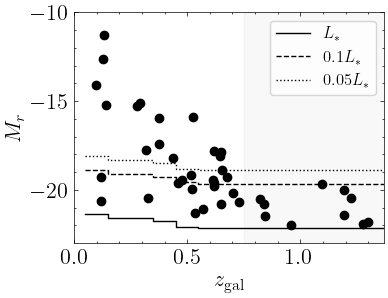

In [46]:
fig, ax = plt.subplots(1, figsize=(4,3))

ax.scatter(df_spec_z_mod['z_gal'], df_spec_z_mod['Mr'])

ax.step(zR_lo, MR_star, where='post',label=r'$L_*$')
ax.step(zR_lo, MR_star-2.5*np.log10(.1), where='post', linestyle='--', color='black',label=r'$0.1L_*$')
ax.step(zR_lo, MR_star-2.5*np.log10(.05), where='post', linestyle=':', color='black',label=r'$0.05L_*$')

ax.axvspan(0.75,1.37,color='grey',alpha=.05)

ax.set_xlim(0,1.37)
ax.set_ylim(-23, -10)
ax.set_xlabel(r'$z_\mathrm{gal}$')
ax.set_ylabel(r'$M_r$')
ax.legend()

In [113]:
zB_lo = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 1.37])
MB_star = np.array([-19.92, -20.04, -20.05, -20.25, -20.44, -20.44])+5*np.log10(0.7)

In [114]:
MB_star

array([-20.6945098, -20.8145098, -20.8245098, -21.0245098, -21.2145098,
       -21.2145098])

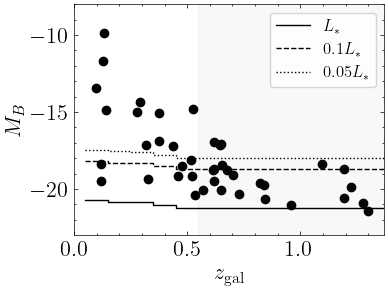

In [48]:
fig, ax = plt.subplots(1, figsize=(4,3))

ax.scatter(df_spec_z_mod['z_gal'], df_spec_z_mod['MB'])

ax.step(zB_lo, MB_star, where='post',label=r'$L_*$')
ax.step(zB_lo, MB_star-2.5*np.log10(.1), where='post', linestyle='--', color='black',label=r'$0.1L_*$')
ax.step(zB_lo, MB_star-2.5*np.log10(.05), where='post', linestyle=':', color='black',label=r'$0.05L_*$')

ax.axvspan(0.55,1.37,color='grey',alpha=.05)

ax.set_xlabel(r'$z_\mathrm{gal}$')
ax.set_ylabel(r'$M_B$')
ax.set_xlim(0,1.37)
ax.set_ylim(-23, -8)

ax.legend()

In [49]:
def compute_Lstar(z,Mr):
    if z<0.15:
        Mr_star = -21.35
    elif 0.15<z<0.25:
        Mr_star = -21.58
    elif 0.25<z<0.35:
        Mr_star = -21.58
    elif 0.35<z<0.45:
        Mr_star = -21.76
    elif 0.45<z<0.55:
        Mr_star = -22.06
    elif z>0.55:
        Mr_star = -22.15
        
    return 10**(-(Mr-Mr_star)/2.5)

In [50]:
z_arr = df_spec_z_mod['z_gal']
Mr_arr = df_spec_z_mod['Mr']
Lstar = []
mfc = []

for i in range(len(z_arr)):
    Lstar.append(compute_Lstar(z_arr[i],Mr_arr[i]))
    if df_spec_z_mod['W(CIV)'][i][0]=='<' or df_spec_z_mod['W(CIV)'][i]=='-1':
        mfc.append('none')
    else:
        mfc.append('black')

Text(0.5, 0, '$d_\\mathrm{proj} \\ (\\mathrm{kpc})$')

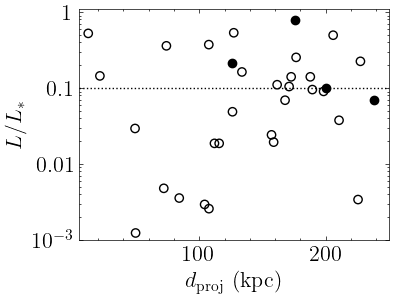

In [51]:
fig, ax = plt.subplots(1, figsize=(4,3))

for i in range(len(z_arr)):
    ax.scatter(df_spec_z_mod['d_proj'][i], Lstar[i], edgecolor='black', facecolor=mfc[i])
ax.axhline(0.1, linestyle=':')

#ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(5,250)
ax.set_ylim(1e-3, 1.1)
#ax.set_xticks([10,100], [r'$10$', r'$100$'])
ax.set_yticks([1e-3,1e-2,1e-1,1], [r'$10^{-3}$', r'$0.01$', r'$0.1$', r'$1$'])

ax.set_ylabel(r'$L/L_*$')
ax.set_xlabel(r'$d_\mathrm{proj} \ (\mathrm{kpc})$')

Print catalog

In [52]:
len(df_spec_z_mod)

41

In [53]:
RA_arr = list(df_spec_z_mod['RA'])
Dec_arr = list(df_spec_z_mod['Dec'])
z_arr = list(df_spec_z_mod['z_gal'])
dv_arr = list(df_spec_z_mod['dv_gal'])
theta_arr = list(df_spec_z_mod['theta'])
d_proj_arr = list(df_spec_z_mod['d_proj'])
f814w_mag_arr = list(df_spec_z_mod['F814W_mag'])
f140w_mag_arr = list(df_spec_z_mod['F140W_mag'])
f160w_mag_arr = list(df_spec_z_mod['F160W_mag'])
Mr_arr = list(df_spec_z_mod['Mr'])
MB_arr = list(df_spec_z_mod['MB'])
logL = np.log10(Lstar)
Mstar15 = list(df_spec_z_mod['M_star15'])
Mstar24 = list(df_spec_z_mod['M_star24'])
W_arr = list(df_spec_z_mod['W(CIV)'])

In [54]:
for i in range(len(W_arr)):
    
    # Case on dv_gal
    if dv_arr[i]=='-1':
        dv_s = '{-}'
    else:
        dv_s = dv_arr[i]
    
    # Case on Mstar
    if z_arr[i]<0.4:
        Mstar = Mstar15[i]
    else:
        Mstar = Mstar24[i]    
    
    if W_arr[i][0]=='<':
        W_s = W_arr[i]
    elif W_arr[i]=='-1':
        W_s = '{-}'
    else:
        W_split = W_arr[i].split(',')
        W_s = W_split[0] + ' \pm ' + W_split[1]
        

    
    print('${:.4f}$ '.format(np.round(RA_arr[i],4)) + '& ${:.4f}$'.format(np.round(Dec_arr[i],4))
          + ' & ${:.4f}$'.format(np.round(z_arr[i],4)) 
          + ' & $' + dv_s + '$'
          + ' & ${:.1f}$'.format(np.round(theta_arr[i],1))
          + ' & ${:.0f}$'.format(np.round(d_proj_arr[i]))
          + ' & ${:.2f}$'.format(np.round(f814w_mag_arr[i],2)) 
          + ' & ${:.2f}$'.format(np.round(f140w_mag_arr[i],2)) 
          + ' & ${:.2f}$'.format(np.round(f160w_mag_arr[i],2)) 
          + ' & ${:.1f}$'.format(np.round(Mr_arr[i],1))
          + ' & ${:.1f}$'.format(np.round(MB_arr[i],1))
          + ' & ${:.1f}$'.format(np.round(logL[i],1))
          + ' & ${:.1f}$'.format(np.round(Mstar,1)) # Redshift dependent prescription
          + ' & $' + W_s + '$ \\\\ ')

$231.1014$ & $9.9823$ & $0.0966$ & ${-}$ & $26.9$ & $50$ & $23.80$ & $22.88$ & $22.66$ & $-14.1$ & $-13.4$ & $-2.9$ & $7.6$ & $<0.04$ \\ 
$231.1028$ & $9.9761$ & $0.1203$ & ${-}$ & $5.2$ & $12$ & $18.03$ & $16.90$ & $16.79$ & $-20.6$ & $-19.5$ & $-0.3$ & $10.4$ & $<0.05$ \\ 
$231.1033$ & $9.9771$ & $0.1204$ & ${-}$ & $9.2$ & $21$ & $19.78$ & $18.48$ & $18.37$ & $-19.2$ & $-18.4$ & $-0.8$ & $9.8$ & $<0.05$ \\ 
$231.1031$ & $9.9792$ & $0.1264$ & ${-}$ & $16.0$ & $37$ & $25.43$ & $23.78$ & $23.56$ & $-12.7$ & $-11.7$ & $-3.5$ & $7.1$ & $<0.04$ \\ 
$231.0981$ & $9.9696$ & $0.1335$ & ${-}$ & $23.5$ & $58$ & $26.46$ & $24.94$ & $24.81$ & $-11.3$ & $-9.8$ & $-4.0$ & $6.7$ & $<0.05$ \\ 
$231.0973$ & $9.9831$ & $0.1393$ & ${-}$ & $34.1$ & $84$ & $23.80$ & $22.78$ & $22.66$ & $-15.2$ & $-14.9$ & $-2.4$ & $7.7$ & $<0.05$ \\ 
$231.0961$ & $9.9714$ & $0.2791$ & ${-}$ & $24.5$ & $104$ & $25.36$ & $23.43$ & $23.28$ & $-15.2$ & $-15.0$ & $-2.5$ & $7.2$ & $<0.1$ \\ 
$231.0981$ & $9.9695$ & $0.2915$ & $

In [55]:
np.min(df_spec_z['z']), np.max(df_spec_z['z'])

(0.0966, 1.2988)

# Plot $W_r$ versus $d_\mathrm{proj}$

This sample

In [56]:
z_arr = np.array(df_spec_z['z'])
d_proj_arr = np.array(df_spec_z['d_proj'])
W_arr = list(df_spec_z['CIV'])

In [57]:
# Adding on some points

#0.1264: 150, 241
#0.1335: 240, 69
#0.5257: 274, 307
#0.6478: 109, 64
#0.8609: 227, 104
#1.1932: 210, 267

ra_list = [231.1031457, 231.0980901, 231.0962013, 231.1054235, 231.0988124, 231.0997568]
dec_list = [9.97920241, 9.96964685, 9.98292463, 9.96942463, 9.97164685, 9.98070241]

In [58]:
theta_list = []

for i in range(len(ra_list)):

    ra = Angle(ra_list[i], units.deg).rad
    dec = Angle(dec_list[i], units.deg).rad

    theta_list.append((calc_phi(ra, dec, qso_ra*np.pi/180, qso_dec*np.pi/180)*units.rad).to(units.arcsecond).value)

In [59]:
theta_list

[16.042666711155547,
 23.54963816243802,
 35.73425245840262,
 22.887641265119314,
 16.420119027286148,
 22.570830899445834]

In [60]:
z_list = [0.1264, 0.1335, 0.5257, 0.6478, 0.8609, 1.1932]

In [61]:
d_proj_list = []

for i in range(len(z_list)):
    z = z_list[i]
    theta = theta_list[i]

    d_proj_list.append(d_A(z)*((theta*units.arcsec).to(units.radian)).value)

In [63]:
d_proj_list

[37.29227510517454,
 58.44249758932393,
 225.50518974202603,
 158.80581440779784,
 127.27926684968014,
 187.7711483434311]

Insert new points and comment out some

In [70]:
# Redshifts
z_arr = np.array([0.0966, 
             0.1203, 
#             0.1204,
             0.1264, # New
             0.1335, # New
             0.1393, 
             0.2791,
             0.2915, 
             0.3198, 
             0.3286,
#             0.3752, 
             0.3759, 
             0.4395, 
             0.4581, 
             0.4784, 
             0.5191, 
             0.5205, 
             0.5257, # New
             0.5356,
             0.5723, 
#             0.6164, 
             0.6174, 
#             0.6178, 
#             0.6183, 
             0.6469, 
#             0.6478, # New
#             0.6518, 
             0.6531,
             0.6780, 
             0.7010, 
             0.7293, 
             0.8217, 
             0.8404, 
             0.8609, # New
             0.9576, 
             1.0959, 
             1.1932, # New
#             1.1935,
             1.2256, 
             1.2787, 
             1.2988])

In [71]:
# Projected distances
d_proj_arr = np.array([49.69739024,  
                 12.26572313,  
#                 21.49279047,  
                 37.29227511, # New
                 58.44249759, # New
                 84.18924492,
                 104.25036257, 
                 107.66609439,  
                 49.26445601,  
                 74.03625782,
#                 112.03124496,  
                 71.98029758, 
                 210.49440733, 
                 171.01506423,
                 198.2802097 , 
                 167.82179554, 
                 172.64086235, 
                 225.5051897, # New
                 205.83108316,
                 107.55205657, 
#                 393.96379803, 
                 115.74721172, 
#                 161.56447745,
#                 189.39780532, 
                 157.12400159, 
#                 158.8058144, # New
#                 286.65526888, 
                 126.26722862,
                 238.07745374, 
                 133.73224539, 
                 176.55247324, 
                 227.38818313,
                 315.35903618, 
                 127.2792668, # New
                 284.4394381, 
                 200.47115099, 
                 187.7711483, # New
#                 276.75187225,
                 126.16111566, 
                 175.42669455, 
                 603.08856133])

In [72]:
# CIV absorption
W_arr = ['<44',
         '<50',
#         '<49',
         '<44', # New
         '<45', # New
         '<49',
         '<105',
         '<97',
         '<157',
         '<123',
#         '<93',
         '<95',
         '<73',
         '<69',
         '<59',
         '<60',
         '<62',
         '<54', # New
         '<47',
         '<48',
#         '<67',
         '<67',
#         '<67',
#         '<58',
         '<46',
#         '<46', # New
#         '<52',
         '<52',
         '157, -18, +18',
         '<49',
         '<49',
         '-10',
         '-10',
         '-10', # New
         '<174',
         '199, -3, +3',
         '<11', # New
#         '<12',
         '16, -3, +3',
         '176, -3, +3',
         '<8']

In [74]:
np.array(W_arr, dtype='str')

array(['<44', '<50', '<44', '<45', '<49', '<105', '<97', '<157', '<123',
       '<95', '<73', '<69', '<59', '<60', '<62', '<54', '<47', '<48',
       '<67', '<46', '<52', '157, -18, +18', '<49', '<49', '-10', '-10',
       '-10', '<174', '199, -3, +3', '<11', '16, -3, +3', '176, -3, +3',
       '<8'], dtype='<U13')

In [75]:
idx = (z_arr>.5)
z_arr = z_arr[idx]
d_proj_arr = d_proj_arr[idx]
W_arr = list(np.array(W_arr, dtype='str')[idx])

In [76]:
len(z_arr), len(d_proj_arr), len(W_arr)

(20, 20, 20)

Chen+01

In [77]:
c01_arr = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/revised_chen01.civ')

d_proj_arr_c01 = c01_arr[:,0]/.7
W_arr_c01 = c01_arr[:,1]
dW_arr_c01 = c01_arr[:,2]
flag_arr_c01 = c01_arr[:,3]
z_arr_c01 = c01_arr[:,4]

In [78]:
np.min(z_arr_c01), np.max(z_arr_c01)

(0.0921, 0.892)

Liang+14 (Sub)

In [79]:
df_l14_sub = pd.read_excel('/Users/thepoetoftwilight/Documents/CUBS/Data/full_catalog_subv4.xlsx')

/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [80]:
#df_l14_sub

In [81]:
d_proj_arr_l14_sub = np.float_(df_l14_sub['imp_dist(kpc)'])
W_arr_l14_sub = np.float_(df_l14_sub['W(CIV1548)'])/1000
dW_arr_l14_sub = np.float_(df_l14_sub['dW(1548)'])/1000
z_arr_l14_sub = np.float_(df_l14_sub['gal_z'])

In [82]:
idx = W_arr_l14_sub!=0

In [83]:
np.sum(idx)

9

In [84]:
d_proj_arr_l14_sub[idx]

array([ 32.432424  ,  39.30282176,  60.641115  ,  74.30470369,
       138.07600254, 192.868363  , 208.217817  , 225.332368  ,
       230.893926  ])

In [85]:
W_arr_l14_sub[idx]

array([0.58590887, 0.30907341, 0.26575392, 0.05860072, 0.05287207,
       0.22019543, 0.09051071, 0.08301023, 0.15472634])

In [86]:
np.min(z_arr_l14_sub), np.max(z_arr_l14_sub)

(0.002389, 0.17597666666666667)

Liang+14 (Full)

In [87]:
df_l14_full = pd.read_excel('/Users/thepoetoftwilight/Documents/CUBS/Data/full_catalog_ions.xlsx')

/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [88]:
#df_l14

In [89]:
d_proj_arr_l14_full = np.float_(df_l14_full['imp_dist(kpc)'])
W_arr_l14_full = np.float_(df_l14_full['W(CIV1548)'])/1000
dW_arr_l14_full = np.float_(df_l14_full['dW(1548)'])/1000
z_arr_l14_full = np.float_(df_l14_full['gal_z'])

In [90]:
idx = W_arr_l14_full!=0

In [91]:
np.sum(idx)

14

In [92]:
d_proj_arr_l14_full[idx]

array([ 32.432424  ,  60.641115  , 230.893926  , 192.868363  ,
       208.217817  , 240.839174  , 242.281241  , 393.06803   ,
         6.75051156,  20.249286  ,  74.30470369, 225.332368  ,
        35.18183576, 138.        ])

In [93]:
W_arr_l14_full[idx]

array([0.58590887, 0.26575392, 0.15472634, 0.22019543, 0.09051071,
       0.25019237, 0.17798263, 0.03027273, 0.13514458, 0.75607771,
       0.05860072, 0.08301023, 0.11253201, 0.062     ])

In [94]:
np.min(z_arr_l14_full), np.max(z_arr_l14_full)

(0.0022066666666666667, 0.17597666666666667)

Compare two catalogs from LC14

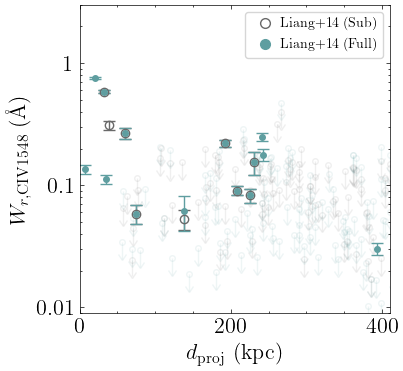

In [95]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Sub)
c = 'dimgrey'
p3 = Line2D([0], [0], label=r'Liang+14 (Sub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor='none', linestyle='')

for i in range(len(d_proj_arr_l14_sub)):
    
    d_proj = d_proj_arr_l14_sub[i]
    W = W_arr_l14_sub[i]
    dW = dW_arr_l14_sub[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', markerfacecolor='none', color=c, 
                         marker='o', markersize=6)
        
# Liang+14 (Full)
c = 'cadetblue'
p6 = Line2D([0], [0], label=r'Liang+14 (Full)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14_full)):
    
    d_proj = d_proj_arr_l14_full[i]
    W = W_arr_l14_full[i]
    dW = dW_arr_l14_full[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,410)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p3,p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

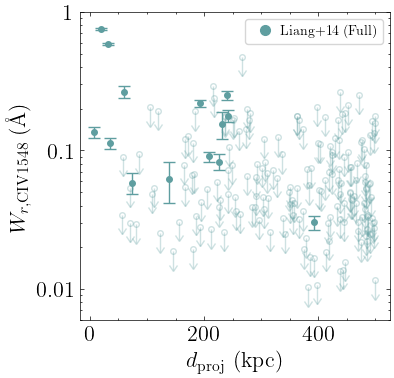

In [96]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Full)
c = 'cadetblue'
p6 = Line2D([0], [0], label=r'Liang+14 (Full)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14_full)):
    
    d_proj = d_proj_arr_l14_full[i]
    W = W_arr_l14_full[i]
    dW = dW_arr_l14_full[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

#ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
#ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

Liang+14 (published)

In [97]:
l14_arr = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/absorber_table.dat', dtype='str')

In [98]:
d_proj_arr_l14 = np.float_(l14_arr[:,2])
W_arr_l14 = np.float_(l14_arr[:,-2])/1000
dW_arr_l14 = np.float_(l14_arr[:,-1])/1000
z_arr_l14 = np.float_(l14_arr[:,3])

In [99]:
idx = W_arr_l14!=0

In [100]:
np.sum(idx)

9

In [101]:
d_proj_arr_l14[idx]

array([ 32.4,  39.3,  60.6,  74.3, 138.1, 192.9, 208.2, 225.3, 230.9])

In [102]:
W_arr_l14[idx]

array([0.586, 0.309, 0.266, 0.059, 0.053, 0.22 , 0.091, 0.083, 0.155])

In [103]:
np.min(z_arr_l14), np.max(z_arr_l14)

(0.0024, 0.176)

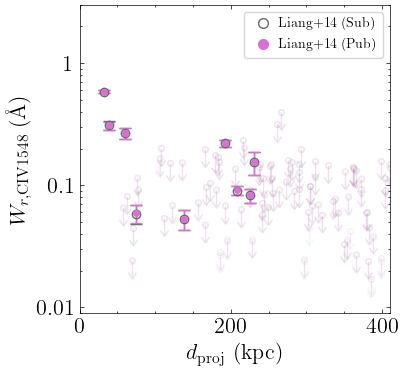

In [104]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Sub)
c = 'dimgrey'
p3 = Line2D([0], [0], label=r'Liang+14 (Sub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor='none', linestyle='')

for i in range(len(d_proj_arr_l14_sub)):
    
    d_proj = d_proj_arr_l14_sub[i]
    W = W_arr_l14_sub[i]
    dW = dW_arr_l14_sub[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', markerfacecolor='none', color=c, 
                         marker='o', markersize=6)
        
# Liang+14 (Pub)
c = 'orchid'
p6 = Line2D([0], [0], label=r'Liang+14 (Pub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,410)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p3,p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

Bordoloi+14

In [105]:
d_proj_arr_b14 = np.array([52,95,90,84,101,65,37,47,37,103,37,77,14,28,15,92,29,
                           125,119,102,120,58,87,135,116,90,89,135,105,101,126,
                           41,124,66,39,55,97,134,114,58,54,53,33])

W_list_b14 = ['173,22', '106,18', '437,33', '393,41', '158,44', '149,39', '406,30',
          '111,35', '152,34', '180,43', '605,28', '452,38', '824,38', '258,83',
          '511,48', '95,30', '201,42', '<14','<19','<18','<20','<16','<58','<18','<17','<29',
          '<44','<15','<28','<21','<34','<16','<17','<59','<45','<39','<35','<25','<32','<29',
          '<19','<19','<25']

W_lim_list_b14 = np.array([30,30,36,57,54,51,51,48,42,75,42,54,42,144,87,54,87,30,45,39,45,36,120,39,
                  39,45,114,30,51,48,72,36,39,156,72,63,72,57,72,39,42,51,45])

z_arr_b14 = np.array([0.017,0.014,0.048,0.055,0.027,0.011,0.034,0.032,0.021,0.030,0.018,0.052,0.059,
             0.062,0.095,0.051,0.095,0.024,0.048,0.023,0.010,0.039,0.036,0.013,0.025,0.023,0.023,0.011,
             0.013,0.026,0.029,0.010,0.026,0.015,0.074,0.104,0.032,0.022,0.028,0.047,0.012,0.018,0.030])

In [106]:
np.min(z_arr_b14), np.max(z_arr_b14)

(0.01, 0.104)

Borthakur+13

In [107]:
d_proj_arr_b13 = np.array([193.9,178.5,171.9,179.1,164.6,152.1,186.6,179.8,88.7,
                           187.4,197.2,196.1,175.5,140.2,146.9,177.0,64.7,103.2,150.9,131.0])

W_list_b13 = ['','<160','<199','<121','928,86','779,172','<295','<231','1224,72','<261','689,37',
            '550,100','','<223','627,105','<248','<134','<485','','<154']

z_arr_b13 = np.array([0.236,0.257,0.297,0.297,0.297,0.295,0.212,0.256,0.473,0.817,0.785,0.195,
                      0.206,0.269,1.240,0.558,0.399,0.229,0.471,0.193])

In [108]:
np.min(z_arr_b13), np.max(z_arr_b13)

(0.193, 1.24)

Make plot

In [109]:
len(d_proj_arr)

20

8 0.052 238.07745374
15 0.174 200.47115099
17 0.011 126.16111566
18 0.016 175.42669455


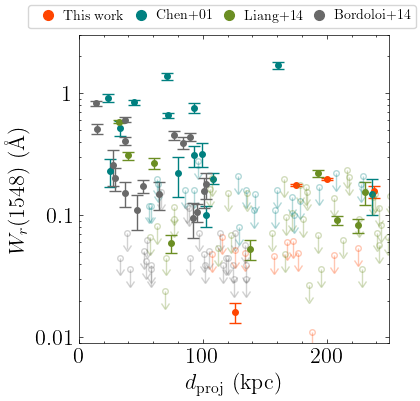

In [110]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# This sample

c = 'orangered'
p1 = Line2D([0], [0], label=r'This work', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr)):
    
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])/1000 # mA to A
        
        
        # Handle d_proj
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
    
    elif W_str !='-10':
        print(i, W, d_proj)
        W_split = W_str.split(',')
        W = float(W_split[0])/1000
        dW = float(W_split[2])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Chen+01

c = 'teal'
p2 = Line2D([0], [0], label=r'Chen+01', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_c01)):
    
    d_proj = d_proj_arr_c01[i]
    W = W_arr_c01[i]
    dW = dW_arr_c01[i]
    f = flag_arr_c01[i]
    
    if f==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Liang+14
c = 'olivedrab'
p3 = Line2D([0], [0], label=r'Liang+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Bordoloi+14
c = 'dimgrey'
p4 = Line2D([0], [0], label=r'Bordoloi+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b14)):
    
    d_proj = d_proj_arr_b14[i]
    W_str = W_list_b14[i]
    W_lim = W_lim_list_b14[i]/1000 # mA to A
    
    if W_str[0]=='<': # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r} (1548) $ (Å)')


# add manual symbols to auto legend
handles.extend([p1,p2,p3,p4])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=4, columnspacing=0.2,handletextpad=0.1,bbox_to_anchor=(1.11, 1.12))

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

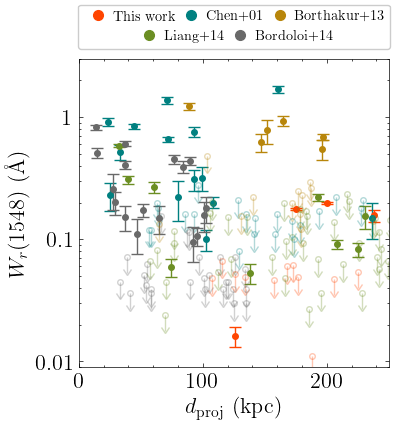

In [112]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.3
handles, labels = plt.gca().get_legend_handles_labels()

# This sample

c = 'orangered'
p1 = Line2D([0], [0], label=r'This work', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr)):
    
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])/1000 # mA to A
        
        
        # Handle d_proj
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])/1000
        dW = float(W_split[2])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Chen+01

c = 'teal'
p2 = Line2D([0], [0], label=r'Chen+01', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_c01)):
    
    d_proj = d_proj_arr_c01[i]
    W = W_arr_c01[i]
    dW = dW_arr_c01[i]
    f = flag_arr_c01[i]
    
    if f==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Liang+14
c = 'olivedrab'
p3 = Line2D([0], [0], label=r'Liang+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Bordoloi+14
c = 'dimgrey'
p4 = Line2D([0], [0], label=r'Bordoloi+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b14)):
    
    d_proj = d_proj_arr_b14[i]
    W_str = W_list_b14[i]
    W_lim = W_lim_list_b14[i]/1000 # mA to A
    
    if W_str[0]=='<': # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Borthakur+13
c = 'darkgoldenrod'
p5 = Line2D([0], [0], label=r'Borthakur+13', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b13)):
    
    d_proj = d_proj_arr_b13[i]
    W_str = W_list_b13[i]
    
    if W_str == '':
        pass
    
    elif W_str[0]=='<': # Non-detection
        W_lim = float(W_str[1:])/1000 # mA to A
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

        
ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r} (1548) $ (Å)')

ax.set_yscale('log')
ax.set_ylim(0.009,3)

# add manual symbols to auto legend
handles.extend([p1,p2,p5,p3,p4])

plt.subplots_adjust(wspace=0, hspace=0)
ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])


ncols = 3
nlines = 5

kw = dict(framealpha=1,
          bbox_to_anchor=(1.02635, 1.2), 
          fontsize=10.3, loc='upper right', handletextpad=0.03,
          columnspacing=0.1)
leg1 = plt.legend(handles=handles[:nlines//ncols*ncols], ncol=ncols, **kw)
plt.gca().add_artist(leg1)
leg2 = plt.legend(handles=handles[nlines//ncols*ncols:], 
                  ncol=nlines-nlines//ncols*ncols,
                  handletextpad=0.03, columnspacing=0.1,
                  fontsize=10.28)

leg2.remove()
leg1._legend_box._children.append(leg2._legend_handle_box)
leg1._legend_box.stale = True

plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

Burchett et al. (2016)

In [110]:
df_b16 = pd.read_csv('/Users/thepoetoftwilight/Documents/CUBS/Data/burchett_low_z.csv')

In [112]:
d_proj_arr_b16 = df_b16['d_proj']
W_list_b16 = list(df_b16['W(CIV)'])

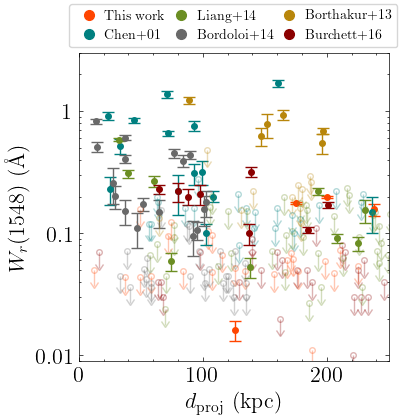

In [125]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.3
handles, labels = plt.gca().get_legend_handles_labels()

# This sample

c = 'orangered'
p1 = Line2D([0], [0], label=r'This work', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr)):
    
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])/1000 # mA to A
        
        
        # Handle d_proj
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])/1000
        dW = float(W_split[2])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Chen+01

c = 'teal'
p2 = Line2D([0], [0], label=r'Chen+01', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_c01)):
    
    d_proj = d_proj_arr_c01[i]
    W = W_arr_c01[i]
    dW = dW_arr_c01[i]
    f = flag_arr_c01[i]
    
    if f==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Liang+14
c = 'olivedrab'
p3 = Line2D([0], [0], label=r'Liang+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Bordoloi+14
c = 'dimgrey'
p4 = Line2D([0], [0], label=r'Bordoloi+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b14)):
    
    d_proj = d_proj_arr_b14[i]
    W_str = W_list_b14[i]
    W_lim = W_lim_list_b14[i]/1000 # mA to A
    
    if W_str[0]=='<': # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Borthakur+13
c = 'darkgoldenrod'
p5 = Line2D([0], [0], label=r'Borthakur+13', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b13)):
    
    d_proj = d_proj_arr_b13[i]
    W_str = W_list_b13[i]
    
    if W_str == '':
        pass
    
    elif W_str[0]=='<': # Non-detection
        W_lim = float(W_str[1:])/1000 # mA to A
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Burchett+16
c = 'darkred'
p6 = Line2D([0], [0], label=r'Burchett+16', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')
        
for i in range(len(d_proj_arr_b16)):
    
    d_proj = d_proj_arr_b16[i]
    W_str = W_list_b16[i]
    
    if W_str[0]=='<': # Non-detection
        W_lim = float(W_str[1:])
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])
        dW = float(W_str_split[1])
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r} (1548) $ (Å)')

ax.set_yscale('log')
ax.set_ylim(0.009,3)

plt.subplots_adjust(wspace=0, hspace=0)
ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

# add manual symbols to auto legend
handles.extend([p1,p2,p3,p4,p5,p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=3, columnspacing=0.2,handletextpad=0.1,bbox_to_anchor=(1.05, 1.18))


# DRAFT

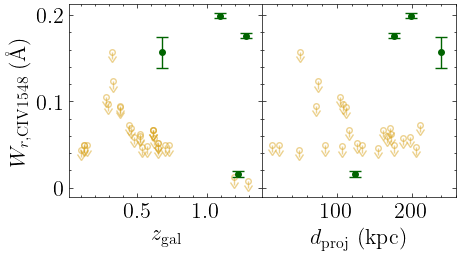

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(2.5*2,2.5), sharey=True)

for i in range(len(z_arr)):
    
    z = z_arr[i]
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])
        
        # Plot marker and spear, z
        (_,caps,_) = axes[0].errorbar(z, W, xerr=None, yerr=5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color='goldenrod', markerfacecolor='none', alpha=.5)
        caps[0].set_fillstyle('none')
        
        # Connect
        axes[0].errorbar(z, W, xerr=None, yerr=[[1.7*5],[0]], markersize=0,
                   linestyle='none', capsize=0, color='goldenrod', alpha=.5)   
        
        # Handle d_proj
        (_,caps,_) = axes[1].errorbar(d_proj, W, xerr=None, yerr=5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color='goldenrod', markerfacecolor='none', alpha=.5)
        caps[0].set_fillstyle('none')
        
        # Connect
        axes[1].errorbar(d_proj, W, xerr=None, yerr=[[1.7*5],[0]], markersize=0,
                   linestyle='none', capsize=0, color='goldenrod', alpha=.5)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])
        dW = float(W_split[2])
        
        # Handle z
        axes[0].errorbar(z, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color='darkgreen', 
                         marker='o', markersize=4)
        
        # Handle d_proj
        axes[1].errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color='darkgreen', 
                         marker='o', markersize=4)
        
axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


axes[1].set_xlim(0.01,260)
axes[1].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')

plt.subplots_adjust(wspace=0, hspace=0)

axes[0].set_yticks([0,100,200], [0,.1,.2])

#plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

In [38]:
def process_data_str(s, non_det_err):
    
    # Check if the point should be plotted or not
    bool_plot = False
    # Coordinate value
    coord_value = np.nan
    # Lower error
    err_lo = 0
    # Upper error
    err_hi = 0
    # Boolean for upper limit
    uplim = False
    # Boolean for lower limit
    lolim = False
    
    # If we don't have an empty string 
    if len(s)!=0:
        
        # Then it needs to be plotted
        bool_plot = True
        
        # Now, check for a non-detection first
        
        # Upper limit
        if s[0] == '<':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only lower error
            uplim = True
            err_lo = non_det_err
            
        # Lower limit
        elif s[0] == '>':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only upper error
            lolim = True
            err_hi = non_det_err
            
        # Detection
        else:
            s_arr = np.array(s.split(','), dtype=float)
            
            # Errors not provided
            if len(s_arr) == 1:
                coord_value = s_arr[0]
                err_lo = 0
                err_hi = 0
                
            # Errors provided
            else:
                coord_value = s_arr[0]
                err_lo = -s_arr[1] # Negative sign to flip the already present negative sign
                err_hi = s_arr[2]
        
    return bool_plot, coord_value, err_lo, err_hi, uplim, lolim

In [39]:
def plot_data_strings(ax, s_x, s_y, c, m, non_det_err_x=0.3, non_det_err_y=0.3, alpha=1):
    
    # First process each data string
    bool_plot_x, coord_value_x, err_lo_x, err_hi_x, uplim_x, lolim_x = process_data_str(s_x, non_det_err_x)
    bool_plot_y, coord_value_y, err_lo_y, err_hi_y, uplim_y, lolim_y = process_data_str(s_y, non_det_err_y)

    ax.errorbar(x=coord_value_x, y=coord_value_y,
                xerr=[[err_lo_x], [err_hi_x]],
                yerr=[[err_lo_y], [err_hi_y]], 
                color=c, alpha=alpha,
                marker=m, markersize=4.5, capsize=2, elinewidth=0.7,
                xuplims = uplim_x, xlolims= lolim_x,
                uplims = uplim_y, lolims= lolim_y) 

Compare column densities and linewidths for species

In [40]:
def compare_plot(ax, list_1, list_2, non_det_err_x, non_det_err_y, c):

    for i in range(len(list_1)):
        
        plot_data_strings(ax, list_1[i], list_2[i], 
                          c, 'o', 
                          non_det_err_x=non_det_err_x, non_det_err_y=non_det_err_y)

In [41]:
#z_list

In [42]:
z_non_det_list = []
d_proj_non_det_list = []
CIV_EW_non_det_list = []

z_det_list = []
d_proj_det_list = []
CIV_EW_det_list = []

for i in range(len(CIV_EW_list)):
    
    if CIV_EW_list[i][0] == '<':
        z_non_det_list.append(z_list[i])
        d_proj_non_det_list.append(d_proj_list[i])
        CIV_EW_non_det_list.append(CIV_EW_list[i])
        
    elif CIV_EW_list[i][0] == '-':
        pass
    
    else:
        z_det_list.append(z_list[i])
        d_proj_det_list.append(d_proj_list[i])
        CIV_EW_det_list.append(CIV_EW_list[i])

In [43]:
z_det_list

['0.678', '1.0959', '1.2256', '1.2787']

In [44]:
d_proj_det_list

['239.03717708741937',
 '199.41643493201175',
 '124.5089103015174',
 '176.0629134202478']

In [45]:
z_non_gal_list = ['1.0443', '1.1659', '1.2594']
CIV_EW_non_gal_list = ['342, -7, +7', '120, -4, +4', '13, -3, +3']

In [46]:
#z_group_list = ['0.6164', '0.6174', '0.6178']
#d_proj_group_list = ['398.253834', '117.581142', '163.708001']
#CIV_EW_group_list = ['254, -22, +22', '254, -22, +22', '254, -22, +22']

Text(0.5, 0, '$d_\\mathrm{proj}$ (kpc)')

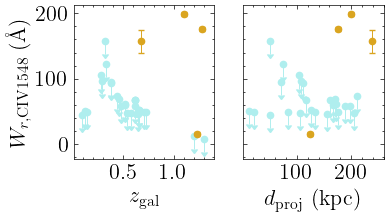

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(2*2,2), sharey=True)

compare_plot(axes[0], z_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[0], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')

compare_plot(axes[1], d_proj_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[1], d_proj_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[1].set_xlim(0.01,260)
axes[1].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')


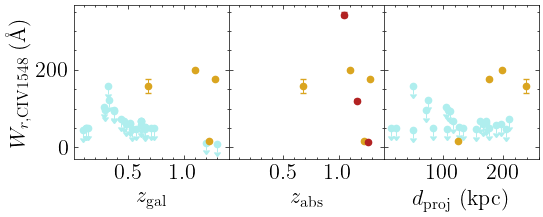

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(3*2,2), sharey=True)

compare_plot(axes[0], z_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[0], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')

axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')

compare_plot(axes[1], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
compare_plot(axes[1], z_non_gal_list, CIV_EW_non_gal_list, 0.3, 20, 'firebrick')
axes[1].set_xlim(0.01,1.4)
axes[1].set_xlabel(r'$z_\mathrm{abs}$')

compare_plot(axes[2], d_proj_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[2], d_proj_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[2].set_xlim(0.01,260)
axes[2].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')

#ax.set_ylim(-6,269)

plt.subplots_adjust(wspace=0, hspace=0)

#plt.savefig(rootdir+'CIV_sample.pdf', dpi=300)